# Ensemble Learning

_Ensemble learning is a method where multiple models are combined instead of using just one. Even if individual models are weak, combining their results gives more accurate and reliable predictions._

* **Multiple Models:** Uses many small models together.
* **Better Accuracy:** Combined results improve performance.
* **Reduced Errors:** Mistakes of one model are balanced by those of others.
* **Simple Idea: Like** taking advice from a group instead of one person.

#### 1. Voting Ensemble

* Voting Ensemble is a technique where multiple different models (not just decision trees) are combined, and their predictions are used to make a final decision.

* Instead of trusting a single model, we let multiple models “vote” and choose the final output.

In [2]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

In [3]:
df = pd.read_csv("../data/Iris.csv")


In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# remove Id col
df = df.iloc[:,1:]

In [7]:
# Label encode Species
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [9]:
df['Species'] = encoder.fit_transform(df['Species'])

In [10]:
df.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


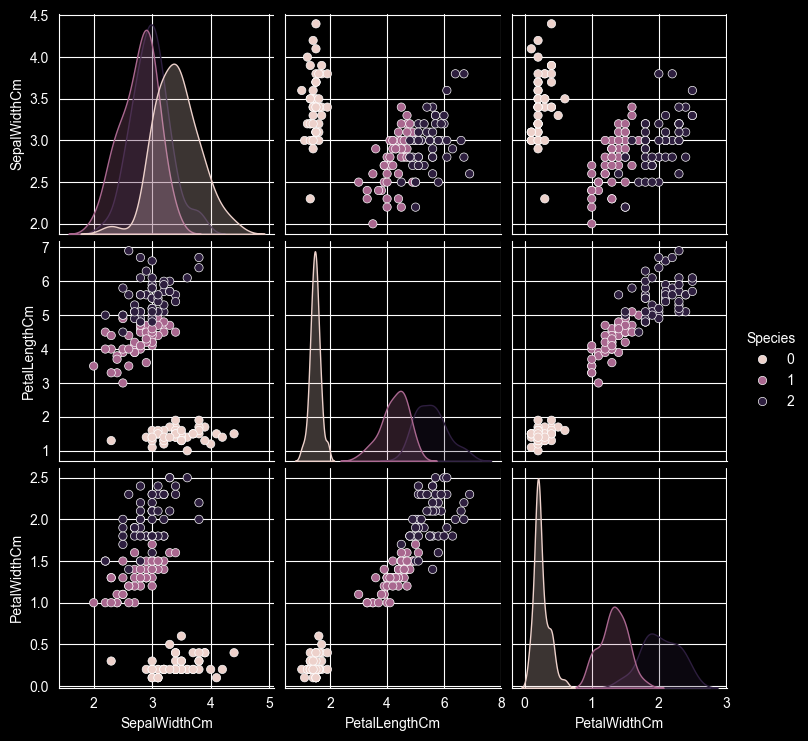

In [11]:
import seaborn as sns
sns.pairplot(df,hue='Species')

In [13]:
df

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0
...,...,...,...,...
145,3.0,5.2,2.3,2
146,2.5,5.0,1.9,2
147,3.0,5.2,2.0,2
148,3.4,5.4,2.3,2


In [16]:
new_df = df[df['Species'] != 0][['PetalLengthCm','PetalWidthCm','SepalWidthCm','Species']]

In [17]:
new_df.head()

,PetalLengthCm,PetalWidthCm,SepalWidthCm,Species
50,4.7,1.4,3.2,1
51,4.5,1.5,3.2,1
52,4.9,1.5,3.1,1
53,4.0,1.3,2.3,1
54,4.6,1.5,2.8,1


In [18]:
new_df.shape

(100, 4)

In [19]:
X = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [22]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [23]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

In [24]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.97
rf 0.96
knn 0.97


In [25]:
from sklearn.ensemble import VotingClassifier

#### a) Hard Voting:

* Used for classification problems
* Each model gives a predicted class
* Final output = most common class

Example:

* Model 1 → Class A
* Model 2 → Class B
* Model 3 → Class A

**Final Prediction = Class A**

In [26]:
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(f"Hard Voting: {np.round(np.mean(x),2)}")

0.97



#### b) Soft Voting (Probability Voting)

* Uses predicted probabilities instead of direct class labels.
* Final output = class with highest average probability.

Example:

* Model 1 → A (0.7), B (0.3)
* Model 2 → A (0.6), B (0.4)
* Model 3 → A (0.8), B (0.2)


**Average → A (0.7), B (0.3)**
**Final Prediction = Class A**

In [28]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(f"Soft Voting:{np.round(np.mean(x),2)}")

Soft Voting:0.96


#### Working

* Train different models (e.g., Logistic Regression, Decision Tree, KNN).
* Each model learns different patterns.
* Combine their predictions using voting.
* Final prediction becomes more reliable.

#### Observation:
* Voting Ensemble gives better accuracy than individual models.
* Logistic Regression performs better after scaling.
* Soft voting improves performance using probabilities.
* It is totally depends on datasets in some case Hard Voting is Better than Soft Voting.
* Decision Tree may overfit, but ensemble reduces its effect.

#### Weighted Voting

In [29]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))


for i=1,j=1,k=1 0.96
for i=1,j=1,k=2 0.95
for i=1,j=1,k=3 0.96
for i=1,j=2,k=1 0.95
for i=1,j=2,k=2 0.95
for i=1,j=2,k=3 0.95
for i=1,j=3,k=1 0.96
for i=1,j=3,k=2 0.95
for i=1,j=3,k=3 0.95
for i=2,j=1,k=1 0.96
for i=2,j=1,k=2 0.95
for i=2,j=1,k=3 0.96
for i=2,j=2,k=1 0.96
for i=2,j=2,k=2 0.96
for i=2,j=2,k=3 0.95
for i=2,j=3,k=1 0.96
for i=2,j=3,k=2 0.96
for i=2,j=3,k=3 0.95
for i=3,j=1,k=1 0.96
for i=3,j=1,k=2 0.95
for i=3,j=1,k=3 0.96
for i=3,j=2,k=1 0.96
for i=3,j=2,k=2 0.96
for i=3,j=2,k=3 0.95
for i=3,j=3,k=1 0.96
for i=3,j=3,k=2 0.96
for i=3,j=3,k=3 0.95


#### Observation:-
* _Weighted voting we see that how the internal working of model with weight assigned in loop Gives iteration wise Accuracy_

* _Helps to get max Accuracy By modifying different Weight_

#### Classifiers on Same Algorithm


**Here, you are using multiple SVM models with different polynomial degrees:**

* degree=1 → simple (linear-like)
* degree=2,3,4,5 → increasing complexity

_**So even though all models are SVM, they learn different patterns.**_

In [30]:
from sklearn.svm import SVC

In [31]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [33]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(f"Accuracy: {np.round(np.mean(x),2)}")

Accuracy: 0.93


#### Observation:-
* Different polynomial degrees create diverse decision boundaries.
* Individual models have varying performance.
* Soft voting combines their strengths.
* Ensemble accuracy (0.93) is higher and more stable.
* Shows that diversity is more important than algorithm type.

### 2.Bagging:
_Bagging or Bootstrap Aggregating, works by training multiple base models independently and in parallel on different random subsets of the training data.These subsets are created using bootstrap sampling, where data points are randomly selected with replacement, allowing some samples to appear multiple times while others may be excluded._

* In classification tasks, the final prediction is decided by majority voting, the class chosen by most base models.
* For regression tasks, predictions are averaged across all base models, known as bagging regression.
* Bagging is versatile and can be applied with various base learners such as decision trees, support vector machines or neural networks.
* Ensemble learning broadly combines multiple models to create stronger predictive systems by leveraging their collective strengths.

#### a)Bagging Classification:

In [110]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [112]:
# Dataset
X, y = make_classification(n_samples=500, n_features=2,
                           n_redundant=0, n_informative=2,
                           random_state=42)


In [113]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [114]:
# Single Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.89


In [115]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(), #base mode
    n_estimators=50, #number of trees
    max_samples=0.8, #Number of sample randomly draw
    bootstrap=True, #sampling with replacement
    random_state=42
)


In [116]:
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.94


##### Cross Validation Score

In [120]:
cv_dt = np.mean(cross_val_score(dt, X, y, cv=10))
cv_bag = np.mean(cross_val_score(bag, X, y, cv=10))

print("DT Cross Validation Accuracy:", round(cv_dt, 3))
print("Bagging Cross Validation Accuracy:", round(cv_bag, 3))

DT Cross Validation Accuracy: 0.924
Bagging Cross Validation Accuracy: 0.938


* Bagging Accuracy (0.94) > Decision Tree (0.89)
* Cross-validation score also improved
* DT → 0.922
* Bagging → 0.938


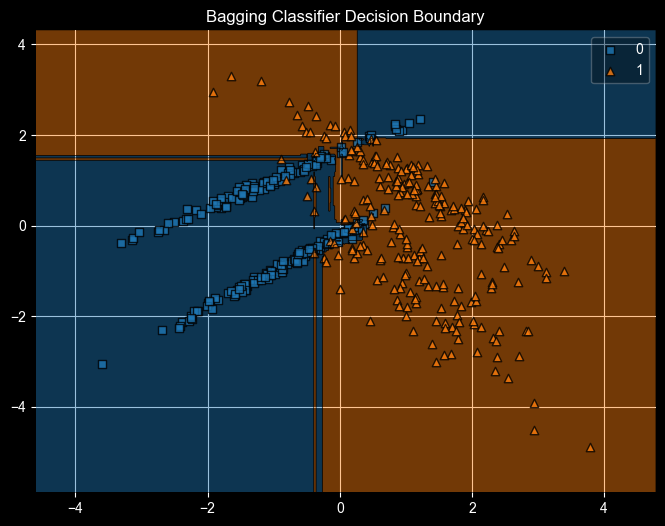

In [118]:
from matplotlib import pyplot as plt

# Plot Decision Boundary (Bagging)

plt.figure(figsize=(8,6))
plot_decision_regions(X, y, clf=bag)
plt.title("Bagging Classifier Decision Boundary")
plt.show()

#### Observation:
* The decision boundary is much smoother compared to a single Decision Tree.
* Less irregular splitting → reduced overfitting.
* Most points are correctly classified → high accuracy (0.94).
* Few misclassified points near boundary → expected in real data.
* Clear separation between classes → good generalization.

#### Pasting:

* bootstrap=False
* Sampling without replacement
* Same row not get reapted

In [121]:
bag_pasting = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=False,   # 👈 change this
    random_state=42,
    n_jobs=-1
)

In [122]:
bag_pasting.fit(X_train, y_train)
y_pred_bag = bag_pasting.predict(X_test)

print("Pasting Accuracy:", accuracy_score(y_test, y_pred_bag))

Pasting Accuracy: 0.93


#### OOB Score:-

_In bagging (bootstrap aggregating) ensemble models like Random Forest, the Out-of-Bag (OOB) score is a performance metric calculated using training data points that were never used to train specific base learners._

* Out-of-Bag (OOB) Data: On average, only about **63.2%** of the original data is used to train any individual base learner (like a decision tree).
*  The remaining **36.8%** of samples are "out-of-bag" for that specific learner.
* **No Separate Validation Set:** It allows for model evaluation and hyperparameter tuning without setting aside a separate validation or test dataset.

In [128]:
bag_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

In [129]:
bag_oob.fit(X_train, y_train)
y_pred_bag = bag_oob.predict(X_test)

In [130]:
bag_oob.oob_score_

0.9275

In [131]:
bag_oob.fit(X_train, y_train)
y_pred_bag = bag_oob.predict(X_test)

print("Pasting Accuracy:", accuracy_score(y_test, y_pred_bag))

Pasting Accuracy: 0.94


#### Observation:-

* Bagging generally gives better results than Pasting.
* Good results come around the 25% to 50% row sampling mark.
* Random patches and subspaces should be used while dealing with high dimensional data.
* To find the correct hyperparameter values we can do GridSearchCV/RandomSearchCV.

#### Applying GridSearchCV : To Estimate correct Hyperparameter

In [132]:
from sklearn.model_selection import GridSearchCV

In [133]:
parameters = {
    'n_estimators': [50,100,500],
    'max_samples': [0.1,0.4,0.7,1.0],
    'bootstrap' : [True,False],
    'max_features' : [0.1,0.4,0.7,1.0]
    }

In [134]:
search = GridSearchCV(BaggingClassifier(), parameters, cv=5)

In [135]:
search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_features': [0.1, 0.4, ...], 'max_samples': [0.1, 0.4, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [138]:
search.best_score_

np.float64(0.9475)

In [137]:
search.best_params_

{'bootstrap': True,
 'max_features': 1.0,
 'max_samples': 0.4,
 'n_estimators': 500}


##### By using GridSearchCV get the new best Parameters:

**{'bootstrap': True,
 'max_features': 1.0,
 'max_samples': 0.4,
 'n_estimators': 500}**


#### Bagging Regressor:


In [143]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, noise=25, random_state=42)


In [144]:
# Sort for visualization
X = np.sort(X, axis=0)

In [145]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [147]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [148]:
from sklearn.metrics import r2_score, mean_squared_error
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))

Decision Tree R2: -1.6044732249726694
Decision Tree MSE: 21471.82685180734


In [146]:
from sklearn.metrics import r2_score, mean_squared_error

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)

bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("Bagging R2:", r2_score(y_test, y_pred_bag))
print("Bagging MSE:", mean_squared_error(y_test, y_pred_bag))

Bagging R2: -0.7996017956047146
Bagging MSE: 14836.296947468712


In [149]:
cv_dt = np.mean(cross_val_score(dt, X, y, cv=10))
cv_bag = np.mean(cross_val_score(bag, X, y, cv=10))

In [150]:
print("DT CV Score:", round(cv_dt, 3))
print("Bagging CV Score:", round(cv_bag, 3))

DT CV Score: -1.056
Bagging CV Score: -0.643


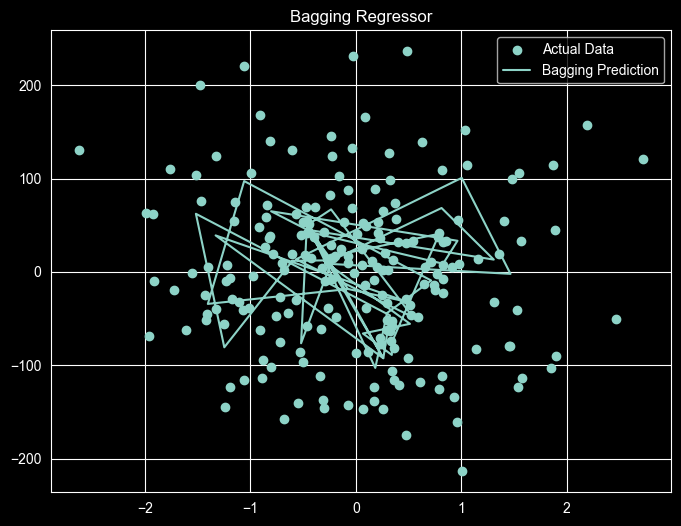

In [151]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, label="Actual Data")
plt.plot(X_test, y_pred_bag, label="Bagging Prediction")
plt.title("Bagging Regressor")
plt.legend()
plt.show()


#### Observation:

* The Decision Tree Regressor performed poorly with an R² score of -1.60, indicating high variance and inability to generalize.
* After applying Bagging, the R² score improved to -0.80, and the Mean Squared Error decreased from 21471 to 14836.
* Additionally, cross-validation scores also improved from -1.056 to -0.643, demonstrating that Bagging reduces variance and enhances model stability, even in challenging datasets.

In [152]:
# Grid Search
grid = GridSearchCV(
    estimator=bag,
    param_grid=parameters,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid.fit(X, y)

# Best Results
print("Best Parameters:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Parameters: {'bootstrap': False, 'max_features': 0.1, 'max_samples': 0.1, 'n_estimators': 500}
Best R2 Score: -0.11402596066215342


#### Observation:
* After applying GridSearchCV, the performance of the Bagging Regressor improved significantly, with the R² score increasing from approximately -0.80 to -0.11.
* The optimal parameters suggest using smaller subsets of data and features with a large number of estimators, which helps in reducing variance and improving generalization.
*  Although the R² score is still slightly negative, the improvement indicates that hyperparameter tuning plays a crucial role in enhancing model performance.